In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

In [3]:
df = pd.read_csv("SummaryofWeather.csv")

C:\Users\MSI\AppData\Local\Temp\ipykernel_1504\3904959827.py:1: DtypeWarning: Columns (7,8,18,25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("SummaryofWeather.csv")


In [4]:
df

,STA,Date,Precip,WindGustSpd,MaxTemp,MinTemp,MeanTemp,Snowfall,PoorWeather,YR,...,FB,FTI,ITH,PGT,TSHDSBRSGF,SD3,RHX,RHN,RVG,WTE
0,10001,1942-7-1,1.016,NaN,25.555556,22.222222,23.888889,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10001,1942-7-2,0,NaN,28.888889,21.666667,25.555556,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10001,1942-7-3,2.54,NaN,26.111111,22.222222,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10001,1942-7-4,2.54,NaN,26.666667,22.222222,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10001,1942-7-5,0,NaN,26.666667,21.666667,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119035,82506,1945-12-27,0,NaN,28.333333,18.333333,23.333333,0.0,NaN,45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
119036,82506,1945-12-28,9.906,NaN,29.444444,18.333333,23.888889,0.0,1.0,45,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
119037,82506,1945-12-29,0,NaN,28.333333,18.333333,23.333333,0.0,1.0,45,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
119038,82506,1945-12-30,0,NaN,28.333333,18.333333,23.333333,0.0,NaN,45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119040 entries, 0 to 119039
Data columns (total 31 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   STA          119040 non-null  int64  
 1   Date         119040 non-null  object 
 2   Precip       119040 non-null  object 
 3   WindGustSpd  532 non-null     float64
 4   MaxTemp      119040 non-null  float64
 5   MinTemp      119040 non-null  float64
 6   MeanTemp     119040 non-null  float64
 7   Snowfall     117877 non-null  object 
 8   PoorWeather  34237 non-null   object 
 9   YR           119040 non-null  int64  
 10  MO           119040 non-null  int64  
 11  DA           119040 non-null  int64  
 12  PRCP         117108 non-null  object 
 13  DR           533 non-null     float64
 14  SPD          532 non-null     float64
 15  MAX          118566 non-null  float64
 16  MIN          118572 non-null  float64
 17  MEA          118542 non-null  float64
 18  SNF          117877 non-

In [6]:
df.describe()

,STA,WindGustSpd,MaxTemp,MinTemp,MeanTemp,YR,MO,DA,DR,SPD,...,FT,FB,FTI,ITH,PGT,SD3,RHX,RHN,RVG,WTE
count,119040.000000,532.000000,119040.000000,119040.000000,119040.000000,119040.000000,119040.000000,119040.000000,533.000000,532.000000,...,0.0,0.0,0.0,0.0,525.000000,0.0,0.0,0.0,0.0,0.0
mean,29659.435795,37.774534,27.045111,17.789511,22.411631,43.805284,6.726016,15.797530,26.998124,20.396617,...,NaN,NaN,NaN,NaN,12.085333,NaN,NaN,NaN,NaN,NaN
std,20953.209402,10.297808,8.717817,8.334572,8.297982,1.136718,3.425561,8.794541,15.221732,5.560371,...,NaN,NaN,NaN,NaN,5.731328,NaN,NaN,NaN,NaN,NaN
min,10001.000000,18.520000,-33.333333,-38.333333,-35.555556,40.000000,1.000000,1.000000,2.000000,10.000000,...,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
25%,11801.000000,29.632000,25.555556,15.000000,20.555556,43.000000,4.000000,8.000000,11.000000,16.000000,...,NaN,NaN,NaN,NaN,8.500000,NaN,NaN,NaN,NaN,NaN
50%,22508.000000,37.040000,29.444444,21.111111,25.555556,44.000000,7.000000,16.000000,32.000000,20.000000,...,NaN,NaN,NaN,NaN,11.600000,NaN,NaN,NaN,NaN,NaN
75%,33501.000000,43.059000,31.666667,23.333333,27.222222,45.000000,10.000000,23.000000,34.000000,23.250000,...,NaN,NaN,NaN,NaN,15.000000,NaN,NaN,NaN,NaN,NaN
max,82506.000000,75.932000,50.000000,34.444444,40.000000,45.000000,12.000000,31.000000,78.000000,41.000000,...,NaN,NaN,NaN,NaN,23.900000,NaN,NaN,NaN,NaN,NaN


In [7]:
df.isnull().sum()

STA                 0
Date                0
Precip              0
WindGustSpd    118508
MaxTemp             0
MinTemp             0
MeanTemp            0
Snowfall         1163
PoorWeather     84803
YR                  0
MO                  0
DA                  0
PRCP             1932
DR             118507
SPD            118508
MAX               474
MIN               468
MEA               498
SNF              1163
SND            113477
FT             119040
FB             119040
FTI            119040
ITH            119040
PGT            118515
TSHDSBRSGF      84803
SD3            119040
RHX            119040
RHN            119040
RVG            119040
WTE            119040
dtype: int64

In [8]:
df.shape

(119040, 31)

In [9]:
df["PRCP"].unique()

array(['0.04', '0', '0.1', 'T', '0.14', '0.02', '0.01', '0.07', '0.13',
       '0.03', '0.22', '0.2', '0.08', '1.01', '1.58', '0.75', '0.94',
       '0.16', '0.48', '0.11', '1.31', '0.76', '1.88', '0.25', '0.12',
       '0.33', '0.4', '1.07', '1.2', '1.78', '0.42', '0.61', '2.27',
       '2.29', '0.45', '1.23', '0.7', '1.06', '1.05', '0.26', '0.21',
       '0.19', '0.3', '0.34', '0.31', '0.49', '3.58', '0.53', '0.47',
       '0.23', '0.17', '0.24', '0.36', '0.18', '0.39', '0.38', '0.06',
       '0.55', '0.68', '1.32', '0.05', '0.54', '0.32', '0.88', '1.54',
       '1.42', '3.86', '0.15', '0.59', '3.08', '5.76', '0.58', '0.86',
       '4.76', '1.66', '0.92', '0.83', '1.77', '0.09', nan, '1.97',
       '0.69', '2.01', '0.28', '1', '0.29', '0.64', '1.84', '0.35',
       '0.97', '0.46', '0.67', '5.7', '0.71', '2', '4.19', '1.44', '2.1',
       '1.37', '0.51', '1.04', '3.37', '1.87', '0.5', '0.44', '2.33',
       '1.33', '1.61', '1.11', '0.98', '0.57', '2.82', '4.02', '1.24',
       '1.43',

In [10]:
df.drop("WindGustSpd",inplace = True,axis = 1)

In [11]:
df.isnull().sum()

STA                 0
Date                0
Precip              0
MaxTemp             0
MinTemp             0
MeanTemp            0
Snowfall         1163
PoorWeather     84803
YR                  0
MO                  0
DA                  0
PRCP             1932
DR             118507
SPD            118508
MAX               474
MIN               468
MEA               498
SNF              1163
SND            113477
FT             119040
FB             119040
FTI            119040
ITH            119040
PGT            118515
TSHDSBRSGF      84803
SD3            119040
RHX            119040
RHN            119040
RVG            119040
WTE            119040
dtype: int64

In [12]:
df.drop(["PoorWeather","DR","SPD","SND","FT","FB","FTI","ITH","PGT","TSHDSBRSGF","SD3","RHX","RHN","RVG","WTE"],inplace = True,axis = 1)

In [13]:
df.isnull().sum()

STA            0
Date           0
Precip         0
MaxTemp        0
MinTemp        0
MeanTemp       0
Snowfall    1163
YR             0
MO             0
DA             0
PRCP        1932
MAX          474
MIN          468
MEA          498
SNF         1163
dtype: int64

In [14]:
df["Snowfall"].unique()

array([0.0, nan, '0', '22.86', '33.02', '30.48', '2.54', '5.08', '10.16',
       '7.62', '20.32', '15.24', '17.78', '12.7', '25.4', '27.94',
       '43.18', '38.1', '45.72', '53.34', '58.42', '66.04', '76.2',
       '81.28', '73.66', '63.5', '50.8', '48.26', '60.96', '55.88',
       '35.56', '78.74', '40.64', '86.36', '83.82', '68.58', '#VALUE!',
       10.16, 7.62, 15.24, 2.54, 5.08, 12.7], dtype=object)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119040 entries, 0 to 119039
Data columns (total 15 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   STA       119040 non-null  int64  
 1   Date      119040 non-null  object 
 2   Precip    119040 non-null  object 
 3   MaxTemp   119040 non-null  float64
 4   MinTemp   119040 non-null  float64
 5   MeanTemp  119040 non-null  float64
 6   Snowfall  117877 non-null  object 
 7   YR        119040 non-null  int64  
 8   MO        119040 non-null  int64  
 9   DA        119040 non-null  int64  
 10  PRCP      117108 non-null  object 
 11  MAX       118566 non-null  float64
 12  MIN       118572 non-null  float64
 13  MEA       118542 non-null  float64
 14  SNF       117877 non-null  object 
dtypes: float64(6), int64(4), object(5)
memory usage: 13.6+ MB


In [16]:
df = df[df['Snowfall'] != '#VALUE!']

In [17]:
df["Snowfall"].unique()

array([0.0, nan, '0', '22.86', '33.02', '30.48', '2.54', '5.08', '10.16',
       '7.62', '20.32', '15.24', '17.78', '12.7', '25.4', '27.94',
       '43.18', '38.1', '45.72', '53.34', '58.42', '66.04', '76.2',
       '81.28', '73.66', '63.5', '50.8', '48.26', '60.96', '55.88',
       '35.56', '78.74', '40.64', '86.36', '83.82', '68.58', 10.16, 7.62,
       15.24, 2.54, 5.08, 12.7], dtype=object)

In [18]:
df['Snowfall'] = df['Snowfall'].astype(float,2)

C:\Users\MSI\AppData\Local\Temp\ipykernel_1504\248641452.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Snowfall'] = df['Snowfall'].astype(float,2)


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 118996 entries, 0 to 119039
Data columns (total 15 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   STA       118996 non-null  int64  
 1   Date      118996 non-null  object 
 2   Precip    118996 non-null  object 
 3   MaxTemp   118996 non-null  float64
 4   MinTemp   118996 non-null  float64
 5   MeanTemp  118996 non-null  float64
 6   Snowfall  117833 non-null  float64
 7   YR        118996 non-null  int64  
 8   MO        118996 non-null  int64  
 9   DA        118996 non-null  int64  
 10  PRCP      117064 non-null  object 
 11  MAX       118522 non-null  float64
 12  MIN       118528 non-null  float64
 13  MEA       118498 non-null  float64
 14  SNF       117833 non-null  object 
dtypes: float64(7), int64(4), object(4)
memory usage: 14.5+ MB


In [20]:
df["Snowfall"].unique()

array([ 0.  ,   nan, 22.86, 33.02, 30.48,  2.54,  5.08, 10.16,  7.62,
       20.32, 15.24, 17.78, 12.7 , 25.4 , 27.94, 43.18, 38.1 , 45.72,
       53.34, 58.42, 66.04, 76.2 , 81.28, 73.66, 63.5 , 50.8 , 48.26,
       60.96, 55.88, 35.56, 78.74, 40.64, 86.36, 83.82, 68.58])

In [21]:
df["Snowfall"].isnull().sum()

np.int64(1163)

In [22]:
df.describe()

,STA,MaxTemp,MinTemp,MeanTemp,Snowfall,YR,MO,DA,MAX,MIN,MEA
count,118996.000000,118996.000000,118996.000000,118996.000000,117833.000000,118996.000000,118996.000000,118996.000000,118522.000000,118528.000000,118498.000000
mean,29664.300153,27.055639,17.799384,22.421823,0.245544,43.805439,6.726478,15.797119,81.022890,64.291745,72.663378
std,20955.555519,8.701262,8.319362,8.281690,2.626600,1.136861,3.425714,8.794234,14.837055,14.452512,14.179453
min,10001.000000,-33.333333,-38.333333,-35.555556,0.000000,40.000000,1.000000,1.000000,-28.000000,-37.000000,-32.000000
25%,11801.000000,25.555556,15.000000,20.555556,0.000000,43.000000,4.000000,8.000000,78.000000,59.000000,69.000000
50%,22508.000000,29.444444,21.111111,25.555556,0.000000,44.000000,7.000000,16.000000,85.000000,70.000000,78.000000
75%,33501.000000,31.666667,23.333333,27.222222,0.000000,45.000000,10.000000,23.000000,89.000000,74.000000,81.000000
max,82506.000000,50.000000,34.444444,40.000000,86.360000,45.000000,12.000000,31.000000,122.000000,94.000000,104.000000


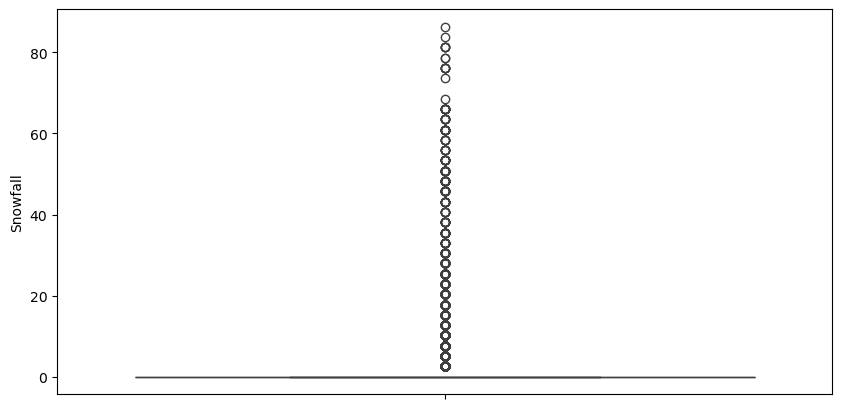

In [23]:
plt.subplots(figsize = (10,5))
plt.subplot(1,1,1)
sns.boxplot(data = df["Snowfall"])
plt.show()

In [24]:
df[df["Snowfall"].isna()]

,STA,Date,Precip,MaxTemp,MinTemp,MeanTemp,Snowfall,YR,MO,DA,PRCP,MAX,MIN,MEA,SNF
2722,10101,1945-4-2,45.212,30.000000,21.666667,26.111111,NaN,45,4,2,1.78,86.0,71.0,79.0,NaN
2746,10101,1945-4-26,3.556,31.111111,24.444444,27.777778,NaN,45,4,26,0.14,88.0,76.0,82.0,NaN
13529,10803,1940-12-26,0,30.555556,22.777778,26.666667,NaN,40,12,26,NaN,87.0,73.0,80.0,NaN
17907,10807,1945-11-19,108.204,30.555556,18.888889,24.444444,NaN,45,11,19,4.26,87.0,66.0,76.0,NaN
30501,11901,1942-10-3,T,-17.777778,-17.777778,-17.777778,NaN,42,10,3,T,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97418,44401,1945-11-12,14.224,2.777778,-1.111111,1.111111,NaN,45,11,12,0.56,37.0,30.0,34.0,NaN
97420,44401,1945-11-14,T,12.777778,2.222222,7.777778,NaN,45,11,14,T,55.0,36.0,46.0,NaN
97525,50301,1943-10-31,0,29.444444,23.333333,26.666667,NaN,43,10,31,NaN,85.0,74.0,80.0,NaN
97590,50301,1944-1-4,0,30.000000,23.888889,26.666667,NaN,44,1,4,NaN,86.0,75.0,80.0,NaN


In [25]:
df.loc[:,"Snowfall"] = df["Snowfall"].fillna(0)

In [26]:
df["Snowfall"].unique()

array([ 0.  , 22.86, 33.02, 30.48,  2.54,  5.08, 10.16,  7.62, 20.32,
       15.24, 17.78, 12.7 , 25.4 , 27.94, 43.18, 38.1 , 45.72, 53.34,
       58.42, 66.04, 76.2 , 81.28, 73.66, 63.5 , 50.8 , 48.26, 60.96,
       55.88, 35.56, 78.74, 40.64, 86.36, 83.82, 68.58])

In [27]:
df.describe()

,STA,MaxTemp,MinTemp,MeanTemp,Snowfall,YR,MO,DA,MAX,MIN,MEA
count,118996.000000,118996.000000,118996.000000,118996.000000,118996.000000,118996.000000,118996.000000,118996.000000,118522.000000,118528.000000,118498.000000
mean,29664.300153,27.055639,17.799384,22.421823,0.243144,43.805439,6.726478,15.797119,81.022890,64.291745,72.663378
std,20955.555519,8.701262,8.319362,8.281690,2.613845,1.136861,3.425714,8.794234,14.837055,14.452512,14.179453
min,10001.000000,-33.333333,-38.333333,-35.555556,0.000000,40.000000,1.000000,1.000000,-28.000000,-37.000000,-32.000000
25%,11801.000000,25.555556,15.000000,20.555556,0.000000,43.000000,4.000000,8.000000,78.000000,59.000000,69.000000
50%,22508.000000,29.444444,21.111111,25.555556,0.000000,44.000000,7.000000,16.000000,85.000000,70.000000,78.000000
75%,33501.000000,31.666667,23.333333,27.222222,0.000000,45.000000,10.000000,23.000000,89.000000,74.000000,81.000000
max,82506.000000,50.000000,34.444444,40.000000,86.360000,45.000000,12.000000,31.000000,122.000000,94.000000,104.000000


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 118996 entries, 0 to 119039
Data columns (total 15 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   STA       118996 non-null  int64  
 1   Date      118996 non-null  object 
 2   Precip    118996 non-null  object 
 3   MaxTemp   118996 non-null  float64
 4   MinTemp   118996 non-null  float64
 5   MeanTemp  118996 non-null  float64
 6   Snowfall  118996 non-null  float64
 7   YR        118996 non-null  int64  
 8   MO        118996 non-null  int64  
 9   DA        118996 non-null  int64  
 10  PRCP      117064 non-null  object 
 11  MAX       118522 non-null  float64
 12  MIN       118528 non-null  float64
 13  MEA       118498 non-null  float64
 14  SNF       117833 non-null  object 
dtypes: float64(7), int64(4), object(4)
memory usage: 14.5+ MB


In [29]:
df.isnull().sum()

STA            0
Date           0
Precip         0
MaxTemp        0
MinTemp        0
MeanTemp       0
Snowfall       0
YR             0
MO             0
DA             0
PRCP        1932
MAX          474
MIN          468
MEA          498
SNF         1163
dtype: int64

In [30]:
df["PRCP"].unique()

array(['0.04', '0', '0.1', 'T', '0.14', '0.02', '0.01', '0.07', '0.13',
       '0.03', '0.22', '0.2', '0.08', '1.01', '1.58', '0.75', '0.94',
       '0.16', '0.48', '0.11', '1.31', '0.76', '1.88', '0.25', '0.12',
       '0.33', '0.4', '1.07', '1.2', '1.78', '0.42', '0.61', '2.27',
       '2.29', '0.45', '1.23', '0.7', '1.06', '1.05', '0.26', '0.21',
       '0.19', '0.3', '0.34', '0.31', '0.49', '3.58', '0.53', '0.47',
       '0.23', '0.17', '0.24', '0.36', '0.18', '0.39', '0.38', '0.06',
       '0.55', '0.68', '1.32', '0.05', '0.54', '0.32', '0.88', '1.54',
       '1.42', '3.86', '0.15', '0.59', '3.08', '5.76', '0.58', '0.86',
       '4.76', '1.66', '0.92', '0.83', '1.77', '0.09', nan, '1.97',
       '0.69', '2.01', '0.28', '1', '0.29', '0.64', '1.84', '0.35',
       '0.97', '0.46', '0.67', '5.7', '0.71', '2', '4.19', '1.44', '2.1',
       '1.37', '0.51', '1.04', '3.37', '1.87', '0.5', '0.44', '2.33',
       '1.33', '1.61', '1.11', '0.98', '0.57', '2.82', '4.02', '1.24',
       '1.43',

In [31]:
df.head()

,STA,Date,Precip,MaxTemp,MinTemp,MeanTemp,Snowfall,YR,MO,DA,PRCP,MAX,MIN,MEA,SNF
0,10001,1942-7-1,1.016,25.555556,22.222222,23.888889,0.0,42,7,1,0.04,78.0,72.0,75.0,0.0
1,10001,1942-7-2,0,28.888889,21.666667,25.555556,0.0,42,7,2,0,84.0,71.0,78.0,0.0
2,10001,1942-7-3,2.54,26.111111,22.222222,24.444444,0.0,42,7,3,0.1,79.0,72.0,76.0,0.0
3,10001,1942-7-4,2.54,26.666667,22.222222,24.444444,0.0,42,7,4,0.1,80.0,72.0,76.0,0.0
4,10001,1942-7-5,0,26.666667,21.666667,24.444444,0.0,42,7,5,0,80.0,71.0,76.0,0.0


In [32]:
df["PRCP"] = df["PRCP"].replace('T',0.01)

C:\Users\MSI\AppData\Local\Temp\ipykernel_1504\3714508199.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["PRCP"] = df["PRCP"].replace('T',0.01)


In [33]:
df["PRCP"].unique()

array(['0.04', '0', '0.1', 0.01, '0.14', '0.02', '0.01', '0.07', '0.13',
       '0.03', '0.22', '0.2', '0.08', '1.01', '1.58', '0.75', '0.94',
       '0.16', '0.48', '0.11', '1.31', '0.76', '1.88', '0.25', '0.12',
       '0.33', '0.4', '1.07', '1.2', '1.78', '0.42', '0.61', '2.27',
       '2.29', '0.45', '1.23', '0.7', '1.06', '1.05', '0.26', '0.21',
       '0.19', '0.3', '0.34', '0.31', '0.49', '3.58', '0.53', '0.47',
       '0.23', '0.17', '0.24', '0.36', '0.18', '0.39', '0.38', '0.06',
       '0.55', '0.68', '1.32', '0.05', '0.54', '0.32', '0.88', '1.54',
       '1.42', '3.86', '0.15', '0.59', '3.08', '5.76', '0.58', '0.86',
       '4.76', '1.66', '0.92', '0.83', '1.77', '0.09', nan, '1.97',
       '0.69', '2.01', '0.28', '1', '0.29', '0.64', '1.84', '0.35',
       '0.97', '0.46', '0.67', '5.7', '0.71', '2', '4.19', '1.44', '2.1',
       '1.37', '0.51', '1.04', '3.37', '1.87', '0.5', '0.44', '2.33',
       '1.33', '1.61', '1.11', '0.98', '0.57', '2.82', '4.02', '1.24',
       '1.43'

In [34]:
df["PRCP"] = df["PRCP"].astype(float,2)

C:\Users\MSI\AppData\Local\Temp\ipykernel_1504\1364946034.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["PRCP"] = df["PRCP"].astype(float,2)


In [35]:
df.describe()

,STA,MaxTemp,MinTemp,MeanTemp,Snowfall,YR,MO,DA,PRCP,MAX,MIN,MEA
count,118996.000000,118996.000000,118996.000000,118996.000000,118996.000000,118996.000000,118996.000000,118996.000000,117064.000000,118522.000000,118528.000000,118498.000000
mean,29664.300153,27.055639,17.799384,22.421823,0.243144,43.805439,6.726478,15.797119,0.130561,81.022890,64.291745,72.663378
std,20955.555519,8.701262,8.319362,8.281690,2.613845,1.136861,3.425714,8.794234,0.428073,14.837055,14.452512,14.179453
min,10001.000000,-33.333333,-38.333333,-35.555556,0.000000,40.000000,1.000000,1.000000,0.000000,-28.000000,-37.000000,-32.000000
25%,11801.000000,25.555556,15.000000,20.555556,0.000000,43.000000,4.000000,8.000000,0.000000,78.000000,59.000000,69.000000
50%,22508.000000,29.444444,21.111111,25.555556,0.000000,44.000000,7.000000,16.000000,0.000000,85.000000,70.000000,78.000000
75%,33501.000000,31.666667,23.333333,27.222222,0.000000,45.000000,10.000000,23.000000,0.040000,89.000000,74.000000,81.000000
max,82506.000000,50.000000,34.444444,40.000000,86.360000,45.000000,12.000000,31.000000,12.100000,122.000000,94.000000,104.000000


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 118996 entries, 0 to 119039
Data columns (total 15 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   STA       118996 non-null  int64  
 1   Date      118996 non-null  object 
 2   Precip    118996 non-null  object 
 3   MaxTemp   118996 non-null  float64
 4   MinTemp   118996 non-null  float64
 5   MeanTemp  118996 non-null  float64
 6   Snowfall  118996 non-null  float64
 7   YR        118996 non-null  int64  
 8   MO        118996 non-null  int64  
 9   DA        118996 non-null  int64  
 10  PRCP      117064 non-null  float64
 11  MAX       118522 non-null  float64
 12  MIN       118528 non-null  float64
 13  MEA       118498 non-null  float64
 14  SNF       117833 non-null  object 
dtypes: float64(8), int64(4), object(3)
memory usage: 14.5+ MB


In [37]:
df.isnull().sum()

STA            0
Date           0
Precip         0
MaxTemp        0
MinTemp        0
MeanTemp       0
Snowfall       0
YR             0
MO             0
DA             0
PRCP        1932
MAX          474
MIN          468
MEA          498
SNF         1163
dtype: int64

In [38]:
df["PRCP"] = df["PRCP"].fillna(df["PRCP"].mean())

C:\Users\MSI\AppData\Local\Temp\ipykernel_1504\494240682.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["PRCP"] = df["PRCP"].fillna(df["PRCP"].mean())


In [39]:
df["PRCP"].head()

0    0.04
1    0.00
2    0.10
3    0.10
4    0.00
Name: PRCP, dtype: float64

In [40]:
df["PRCP"].unique()

array([4.00000000e-02, 0.00000000e+00, 1.00000000e-01, 1.00000000e-02,
       1.40000000e-01, 2.00000000e-02, 7.00000000e-02, 1.30000000e-01,
       3.00000000e-02, 2.20000000e-01, 2.00000000e-01, 8.00000000e-02,
       1.01000000e+00, 1.58000000e+00, 7.50000000e-01, 9.40000000e-01,
       1.60000000e-01, 4.80000000e-01, 1.10000000e-01, 1.31000000e+00,
       7.60000000e-01, 1.88000000e+00, 2.50000000e-01, 1.20000000e-01,
       3.30000000e-01, 4.00000000e-01, 1.07000000e+00, 1.20000000e+00,
       1.78000000e+00, 4.20000000e-01, 6.10000000e-01, 2.27000000e+00,
       2.29000000e+00, 4.50000000e-01, 1.23000000e+00, 7.00000000e-01,
       1.06000000e+00, 1.05000000e+00, 2.60000000e-01, 2.10000000e-01,
       1.90000000e-01, 3.00000000e-01, 3.40000000e-01, 3.10000000e-01,
       4.90000000e-01, 3.58000000e+00, 5.30000000e-01, 4.70000000e-01,
       2.30000000e-01, 1.70000000e-01, 2.40000000e-01, 3.60000000e-01,
       1.80000000e-01, 3.90000000e-01, 3.80000000e-01, 6.00000000e-02,
      

In [41]:
df.describe()

,STA,MaxTemp,MinTemp,MeanTemp,Snowfall,YR,MO,DA,PRCP,MAX,MIN,MEA
count,118996.000000,118996.000000,118996.000000,118996.000000,118996.000000,118996.000000,118996.000000,118996.000000,118996.000000,118522.000000,118528.000000,118498.000000
mean,29664.300153,27.055639,17.799384,22.421823,0.243144,43.805439,6.726478,15.797119,0.130561,81.022890,64.291745,72.663378
std,20955.555519,8.701262,8.319362,8.281690,2.613845,1.136861,3.425714,8.794234,0.424584,14.837055,14.452512,14.179453
min,10001.000000,-33.333333,-38.333333,-35.555556,0.000000,40.000000,1.000000,1.000000,0.000000,-28.000000,-37.000000,-32.000000
25%,11801.000000,25.555556,15.000000,20.555556,0.000000,43.000000,4.000000,8.000000,0.000000,78.000000,59.000000,69.000000
50%,22508.000000,29.444444,21.111111,25.555556,0.000000,44.000000,7.000000,16.000000,0.000000,85.000000,70.000000,78.000000
75%,33501.000000,31.666667,23.333333,27.222222,0.000000,45.000000,10.000000,23.000000,0.050000,89.000000,74.000000,81.000000
max,82506.000000,50.000000,34.444444,40.000000,86.360000,45.000000,12.000000,31.000000,12.100000,122.000000,94.000000,104.000000


In [42]:
df.isnull().sum()

STA            0
Date           0
Precip         0
MaxTemp        0
MinTemp        0
MeanTemp       0
Snowfall       0
YR             0
MO             0
DA             0
PRCP           0
MAX          474
MIN          468
MEA          498
SNF         1163
dtype: int64

In [43]:
df["MAX"].unique()

array([ 78.,  84.,  79.,  80.,  83.,  81.,  76.,  82.,  77.,  75.,  91.,
        86.,  88.,  94.,  87.,  85.,  89.,  90.,  92.,  93.,  95.,  74.,
        70.,  96.,  97.,  98.,  99.,  nan,  73.,  72.,  68.,  71.,  69.,
        65.,  67.,  66., 100., 102., 101.,  63.,  62.,  64.,  61.,  59.,
        60., 105., 107., 103., 104., 108., 106., 109., 112., 115., 117.,
       113., 116., 111., 114., 110.,  58.,  56.,  52.,  55.,  53.,  57.,
        54.,  46.,  50.,  47.,  51.,  44.,  49.,  48.,  45.,  43.,  34.,
        37.,  39.,  42.,  36.,  38.,  40.,  28.,  26.,  24.,  29.,  35.,
        30.,  22.,  31.,  19.,  27.,  15.,  41.,  32.,  33.,  13.,  11.,
        23.,  25.,  12.,  21.,  17.,  18.,  16.,  14.,  20.,   6.,   8.,
         4.,   9.,   7.,  10.,   5.,   2.,   3.,   1.,  -3.,  -5.,  -1.,
         0.,  -2.,  -6., -17., -12., -10., -20., -15.,  -8., -22., -11.,
        -4., -18.,  -9., -23., -13., -25., -14.,  -7., -16., -26., -28.,
       -27., -24., 118., 119., 120., 122., 121.])

In [44]:
df["MAX"].head()

0    78.0
1    84.0
2    79.0
3    80.0
4    80.0
Name: MAX, dtype: float64

In [45]:
df["MAX"] = df["MAX"].fillna(df["MAX"].mean())

C:\Users\MSI\AppData\Local\Temp\ipykernel_1504\3242623652.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["MAX"] = df["MAX"].fillna(df["MAX"].mean())


In [46]:
df.isnull().sum()

STA            0
Date           0
Precip         0
MaxTemp        0
MinTemp        0
MeanTemp       0
Snowfall       0
YR             0
MO             0
DA             0
PRCP           0
MAX            0
MIN          468
MEA          498
SNF         1163
dtype: int64

In [47]:
df["MIN"].unique()

array([ 72.,  71.,  73.,  70.,  68.,  69.,  66.,  67.,  64.,  74.,  75.,
        63.,  61.,  62.,  65.,  76.,  77.,  78.,  80.,  79.,  82.,  81.,
        83.,  59.,  nan,  56.,  60.,  57.,  58.,  55.,  54.,  53.,  51.,
        52.,  84.,  50.,  48.,  47.,  49.,  46.,  41.,  44.,  42.,  43.,
        45.,  87.,  88.,  86.,  91.,  38.,  40.,  36.,  35.,  37.,  39.,
        34.,  33.,  32.,  85.,  90.,  30.,  29.,  89.,  93.,  92.,  31.,
        28.,  24.,  25.,  19.,  22.,  18.,  17.,  13.,  15.,  26.,   9.,
         8.,  12.,  10.,   7.,   6.,  20.,  14.,  27.,  23.,   5.,  21.,
        11.,  16.,   4.,   2.,  -3.,  -7.,  -2.,  -4.,   3., -11.,  -6.,
        -8.,  -5.,  -1.,   1., -10., -12., -15., -14., -13.,   0., -17.,
        -9., -21., -26., -22., -28., -29., -16., -25., -31., -30., -18.,
       -19., -20., -36., -27., -35., -34., -23., -24., -32., -33., -37.,
        94.])

In [48]:
df["MIN"] = df["MIN"].fillna(df["MIN"].mean())


C:\Users\MSI\AppData\Local\Temp\ipykernel_1504\4244606177.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["MIN"] = df["MIN"].fillna(df["MIN"].mean())


In [49]:
df.isnull().sum()

STA            0
Date           0
Precip         0
MaxTemp        0
MinTemp        0
MeanTemp       0
Snowfall       0
YR             0
MO             0
DA             0
PRCP           0
MAX            0
MIN            0
MEA          498
SNF         1163
dtype: int64

In [50]:
df["MEA"].unique()

array([ 75.,  78.,  76.,  77.,  74.,  73.,  72.,  71.,  79.,  83.,  80.,
        81.,  82.,  84.,  85.,  69.,  86.,  87.,  70.,  nan,  88.,  89.,
        68.,  67.,  66.,  65.,  64.,  63.,  62.,  60.,  90.,  57.,  58.,
        61.,  59.,  56.,  54.,  52.,  51.,  53.,  55.,  92.,  96.,  91.,
        94.,  93.,  98.,  97., 102., 100.,  95., 101.,  49.,  48.,  50.,
        47.,  99.,  45.,  46.,  44.,  40.,  42.,  43.,  39.,  38.,  41.,
        29.,  34.,  36.,  35.,  37.,  26.,  28.,  23.,  22.,  20.,  30.,
        24.,  16.,  19.,  21.,  18.,  11.,  10.,  25.,  27.,  32.,  31.,
        33.,   8.,  14.,  15.,  13.,  12.,  17.,   7.,   6.,   0.,  -2.,
         3.,   9.,  -1.,   2.,   4.,   5.,  -3.,  -5.,  -4.,   1.,  -8.,
        -6., -10.,  -7., -11., -22., -17., -16., -24., -12., -15., -26.,
       -20., -18.,  -9., -14., -13., -30., -19., -21., -23., -28., -25.,
       -32., -31., -29., 104., 103.])

In [51]:
df["MEA"].describe()

count    118498.000000
mean         72.663378
std          14.179453
min         -32.000000
25%          69.000000
50%          78.000000
75%          81.000000
max         104.000000
Name: MEA, dtype: float64

In [52]:
df["MEA"] = df["MEA"].fillna(df["MEA"].mean())

C:\Users\MSI\AppData\Local\Temp\ipykernel_1504\3238923988.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["MEA"] = df["MEA"].fillna(df["MEA"].mean())


In [53]:
df["SNF"].unique()

array([0.0, nan, '0', '0.9', '1.3', '1.2', '0.1', '0.2', '0.4', '0.3',
       '0.8', '0.6', '0.7', '0.5', '1', '1.1', '1.7', '1.5', '1.8', '2.1',
       '2.3', '2.6', '3', '3.2', '2.9', '2.5', '2', '1.9', '2.4', '2.2',
       '1.4', '3.1', '1.6', '3.4', '3.3', '2.7', 0.4, 0.3, 0.6, 0.1, 0.2,
       0.5], dtype=object)

In [54]:
df["SNF"] = df["SNF"].astype(float,1)

C:\Users\MSI\AppData\Local\Temp\ipykernel_1504\3049483085.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["SNF"] = df["SNF"].astype(float,1)


In [55]:
df["SNF"].unique()

array([0. , nan, 0.9, 1.3, 1.2, 0.1, 0.2, 0.4, 0.3, 0.8, 0.6, 0.7, 0.5,
       1. , 1.1, 1.7, 1.5, 1.8, 2.1, 2.3, 2.6, 3. , 3.2, 2.9, 2.5, 2. ,
       1.9, 2.4, 2.2, 1.4, 3.1, 1.6, 3.4, 3.3, 2.7])

In [56]:
df.describe()

,STA,MaxTemp,MinTemp,MeanTemp,Snowfall,YR,MO,DA,PRCP,MAX,MIN,MEA,SNF
count,118996.000000,118996.000000,118996.000000,118996.000000,118996.000000,118996.000000,118996.000000,118996.000000,118996.000000,118996.000000,118996.000000,118996.000000,117833.000000
mean,29664.300153,27.055639,17.799384,22.421823,0.243144,43.805439,6.726478,15.797119,0.130561,81.022890,64.291745,72.663378,0.009667
std,20955.555519,8.701262,8.319362,8.281690,2.613845,1.136861,3.425714,8.794234,0.424584,14.807475,14.424064,14.149751,0.103409
min,10001.000000,-33.333333,-38.333333,-35.555556,0.000000,40.000000,1.000000,1.000000,0.000000,-28.000000,-37.000000,-32.000000,0.000000
25%,11801.000000,25.555556,15.000000,20.555556,0.000000,43.000000,4.000000,8.000000,0.000000,78.000000,59.000000,69.000000,0.000000
50%,22508.000000,29.444444,21.111111,25.555556,0.000000,44.000000,7.000000,16.000000,0.000000,85.000000,70.000000,78.000000,0.000000
75%,33501.000000,31.666667,23.333333,27.222222,0.000000,45.000000,10.000000,23.000000,0.050000,89.000000,74.000000,81.000000,0.000000
max,82506.000000,50.000000,34.444444,40.000000,86.360000,45.000000,12.000000,31.000000,12.100000,122.000000,94.000000,104.000000,3.400000


In [57]:
df["SNF"] = df["SNF"].fillna(df["SNF"].std())

C:\Users\MSI\AppData\Local\Temp\ipykernel_1504\707165234.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["SNF"] = df["SNF"].fillna(df["SNF"].std())


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 118996 entries, 0 to 119039
Data columns (total 15 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   STA       118996 non-null  int64  
 1   Date      118996 non-null  object 
 2   Precip    118996 non-null  object 
 3   MaxTemp   118996 non-null  float64
 4   MinTemp   118996 non-null  float64
 5   MeanTemp  118996 non-null  float64
 6   Snowfall  118996 non-null  float64
 7   YR        118996 non-null  int64  
 8   MO        118996 non-null  int64  
 9   DA        118996 non-null  int64  
 10  PRCP      118996 non-null  float64
 11  MAX       118996 non-null  float64
 12  MIN       118996 non-null  float64
 13  MEA       118996 non-null  float64
 14  SNF       118996 non-null  float64
dtypes: float64(9), int64(4), object(2)
memory usage: 14.5+ MB


In [59]:
df["Precip"].unique()

array(['1.016', '0', '2.54', 'T', '3.556', '0.508', '0.254', '1.778',
       '3.302', '0.762', '5.588', '5.08', '2.032', '25.654', '40.132',
       '19.05', '23.876', '4.064', '12.192', '2.794', '33.274', '19.304',
       '47.752', '6.35', '3.048', '8.382', '10.16', '27.178', '30.48',
       '45.212', '10.668', '15.494', '57.658', '58.166', '11.43',
       '31.242', '17.78', '26.924', '26.67', '6.604', '5.334', '4.826',
       '7.62', '8.636', '7.874', '12.446', '90.932', '13.462', '11.938',
       '5.842', '4.318', '6.096', '9.144', '4.572', '9.906', '9.652',
       '1.524', '13.97', '17.272', '33.528', '1.27', '13.716', '8.128',
       '22.352', '39.116', '36.068', '98.044', '3.81', '14.986', '78.232',
       '146.304', '14.732', '21.844', '120.904', '42.164', '23.368',
       '21.082', '44.958', '2.286', '50.038', '17.526', '51.054', '7.112',
       '25.4', '7.366', '16.256', '46.736', '8.89', '24.638', '11.684',
       '17.018', '144.78', '18.034', '50.8', '106.426', '36.576', '53.

In [60]:
df['Precip'] = df["Precip"].replace('T',1)

C:\Users\MSI\AppData\Local\Temp\ipykernel_1504\1089580580.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Precip'] = df["Precip"].replace('T',1)


In [61]:
df['Precip'] = df['Precip'].astype(float,2) 

C:\Users\MSI\AppData\Local\Temp\ipykernel_1504\3580251830.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Precip'] = df['Precip'].astype(float,2)


In [62]:
df['Precip'].unique()

array([1.01600e+00, 0.00000e+00, 2.54000e+00, 1.00000e+00, 3.55600e+00,
       5.08000e-01, 2.54000e-01, 1.77800e+00, 3.30200e+00, 7.62000e-01,
       5.58800e+00, 5.08000e+00, 2.03200e+00, 2.56540e+01, 4.01320e+01,
       1.90500e+01, 2.38760e+01, 4.06400e+00, 1.21920e+01, 2.79400e+00,
       3.32740e+01, 1.93040e+01, 4.77520e+01, 6.35000e+00, 3.04800e+00,
       8.38200e+00, 1.01600e+01, 2.71780e+01, 3.04800e+01, 4.52120e+01,
       1.06680e+01, 1.54940e+01, 5.76580e+01, 5.81660e+01, 1.14300e+01,
       3.12420e+01, 1.77800e+01, 2.69240e+01, 2.66700e+01, 6.60400e+00,
       5.33400e+00, 4.82600e+00, 7.62000e+00, 8.63600e+00, 7.87400e+00,
       1.24460e+01, 9.09320e+01, 1.34620e+01, 1.19380e+01, 5.84200e+00,
       4.31800e+00, 6.09600e+00, 9.14400e+00, 4.57200e+00, 9.90600e+00,
       9.65200e+00, 1.52400e+00, 1.39700e+01, 1.72720e+01, 3.35280e+01,
       1.27000e+00, 1.37160e+01, 8.12800e+00, 2.23520e+01, 3.91160e+01,
       3.60680e+01, 9.80440e+01, 3.81000e+00, 1.49860e+01, 7.823

In [63]:
df.tail()

,STA,Date,Precip,MaxTemp,MinTemp,MeanTemp,Snowfall,YR,MO,DA,PRCP,MAX,MIN,MEA,SNF
119035,82506,1945-12-27,0.000,28.333333,18.333333,23.333333,0.0,45,12,27,0.00,83.0,65.0,74.0,0.0
119036,82506,1945-12-28,9.906,29.444444,18.333333,23.888889,0.0,45,12,28,0.39,85.0,65.0,75.0,0.0
119037,82506,1945-12-29,0.000,28.333333,18.333333,23.333333,0.0,45,12,29,0.00,83.0,65.0,74.0,0.0
119038,82506,1945-12-30,0.000,28.333333,18.333333,23.333333,0.0,45,12,30,0.00,83.0,65.0,74.0,0.0
119039,82506,1945-12-31,0.000,29.444444,17.222222,23.333333,0.0,45,12,31,0.00,85.0,63.0,74.0,0.0


In [64]:
df.drop('Date',inplace = True,axis = 1)

C:\Users\MSI\AppData\Local\Temp\ipykernel_1504\918286278.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop('Date',inplace = True,axis = 1)


In [65]:
df.corr()

,STA,Precip,MaxTemp,MinTemp,MeanTemp,Snowfall,YR,MO,DA,PRCP,MAX,MIN,MEA,SNF
STA,1.000000,0.013056,0.091811,0.058698,0.077513,-0.057741,0.121339,-0.008678,0.000932,0.013237,0.083190,0.050049,0.068998,-0.063060
Precip,0.013056,1.000000,0.002251,0.088765,0.046079,-0.010676,0.007600,0.037946,0.000658,0.998907,0.001901,0.092008,0.048046,-0.011981
MaxTemp,0.091811,0.002251,1.000000,0.877921,0.968926,-0.322799,0.039198,0.030886,-0.004954,0.000942,0.945423,0.825633,0.915238,-0.345241
MinTemp,0.058698,0.088765,0.877921,1.000000,0.965292,-0.308584,-0.021224,0.068711,-0.002351,0.086568,0.841162,0.963219,0.930892,-0.328594
MeanTemp,0.077513,0.046079,0.968926,0.965292,1.000000,-0.324483,0.010232,0.050348,-0.003948,0.044209,0.919061,0.917433,0.949199,-0.346327
Snowfall,-0.057741,-0.010676,-0.322799,-0.308584,-0.324483,1.000000,-0.001033,-0.044559,-0.000240,-0.011414,-0.341181,-0.320142,-0.341709,0.995141
YR,0.121339,0.007600,0.039198,-0.021224,0.010232,-0.001033,1.000000,-0.144497,-0.011134,0.006107,0.013440,-0.043680,-0.015189,0.000542
MO,-0.008678,0.037946,0.030886,0.068711,0.050348,-0.044559,-0.144497,1.000000,0.006677,0.037174,0.033792,0.071969,0.054318,-0.046465
DA,0.000932,0.000658,-0.004954,-0.002351,-0.003948,-0.000240,-0.011134,0.006677,1.000000,0.000838,-0.003100,-0.000499,-0.001867,-0.000560
PRCP,0.013237,0.998907,0.000942,0.086568,0.044209,-0.011414,0.006107,0.037174,0.000838,1.000000,0.000499,0.089795,0.046185,-0.012224


<Axes: >

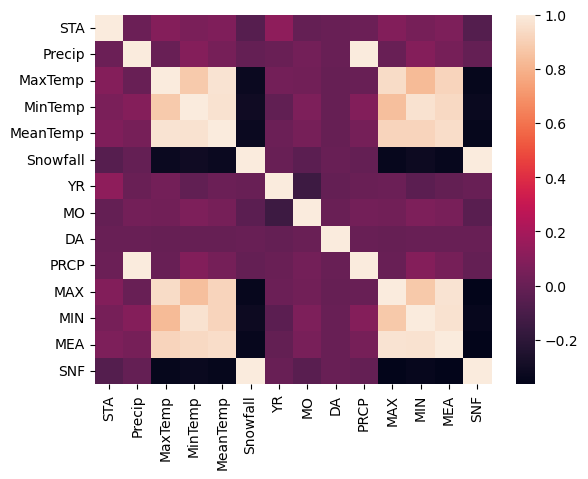

In [66]:
sns.heatmap(df.corr())

In [67]:
X = df.drop(["PRCP"],axis = 1)
y = df["PRCP"]

In [68]:
X

,STA,Precip,MaxTemp,MinTemp,MeanTemp,Snowfall,YR,MO,DA,MAX,MIN,MEA,SNF
0,10001,1.016,25.555556,22.222222,23.888889,0.0,42,7,1,78.0,72.0,75.0,0.0
1,10001,0.000,28.888889,21.666667,25.555556,0.0,42,7,2,84.0,71.0,78.0,0.0
2,10001,2.540,26.111111,22.222222,24.444444,0.0,42,7,3,79.0,72.0,76.0,0.0
3,10001,2.540,26.666667,22.222222,24.444444,0.0,42,7,4,80.0,72.0,76.0,0.0
4,10001,0.000,26.666667,21.666667,24.444444,0.0,42,7,5,80.0,71.0,76.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
119035,82506,0.000,28.333333,18.333333,23.333333,0.0,45,12,27,83.0,65.0,74.0,0.0
119036,82506,9.906,29.444444,18.333333,23.888889,0.0,45,12,28,85.0,65.0,75.0,0.0
119037,82506,0.000,28.333333,18.333333,23.333333,0.0,45,12,29,83.0,65.0,74.0,0.0
119038,82506,0.000,28.333333,18.333333,23.333333,0.0,45,12,30,83.0,65.0,74.0,0.0


In [69]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.15,random_state = 15)

In [70]:
X_train
X_test

,STA,Precip,MaxTemp,MinTemp,MeanTemp,Snowfall,YR,MO,DA,MAX,MIN,MEA,SNF
553,10001,0.000,31.111111,23.333333,27.222222,0.0,44,1,5,88.0,74.0,81.0,0.0
94942,34147,0.000,15.555556,3.888889,10.000000,0.0,45,10,5,60.0,39.0,50.0,0.0
71753,32701,11.176,33.333333,24.444444,28.888889,0.0,45,8,29,92.0,76.0,84.0,0.0
87687,33401,0.000,14.444444,7.222222,11.111111,0.0,44,12,19,58.0,45.0,52.0,0.0
78536,32907,0.762,25.000000,12.777778,18.888889,0.0,44,2,19,77.0,55.0,66.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21361,11601,4.572,30.555556,23.333333,26.666667,0.0,45,12,7,87.0,74.0,80.0,0.0
98943,50302,1.000,30.000000,21.111111,25.555556,0.0,45,8,30,86.0,70.0,78.0,0.0
58684,22508,1.000,23.333333,18.333333,21.111111,0.0,42,3,18,74.0,65.0,70.0,0.0
90914,34018,0.000,31.666667,19.444444,25.555556,0.0,45,7,8,89.0,67.0,78.0,0.0


In [71]:
scaler = StandardScaler()
linear = LinearRegression()

In [72]:
def correlation_for_dropping(df,threshold):
    columns_to_drop = set()
    corr = df.corr()
    for i in range(len(corr.columns)):
        for j in range (i):
            if abs(corr.iloc[i,j]) > threshold:
                columns_to_drop.add(corr.columns[i])
    return columns_to_drop

In [73]:
columns_dropping = correlation_for_dropping(X_train,0.85)
columns_dropping

{'MAX', 'MEA', 'MIN', 'MeanTemp', 'MinTemp', 'SNF'}

In [74]:
X_train.drop(columns_dropping,axis = 1,inplace = True)
X_test.drop(columns_dropping,axis = 1,inplace = True)

In [77]:
X_train.columns

Index(['STA', 'Precip', 'MaxTemp', 'Snowfall', 'YR', 'MO', 'DA'], dtype='object')

In [83]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

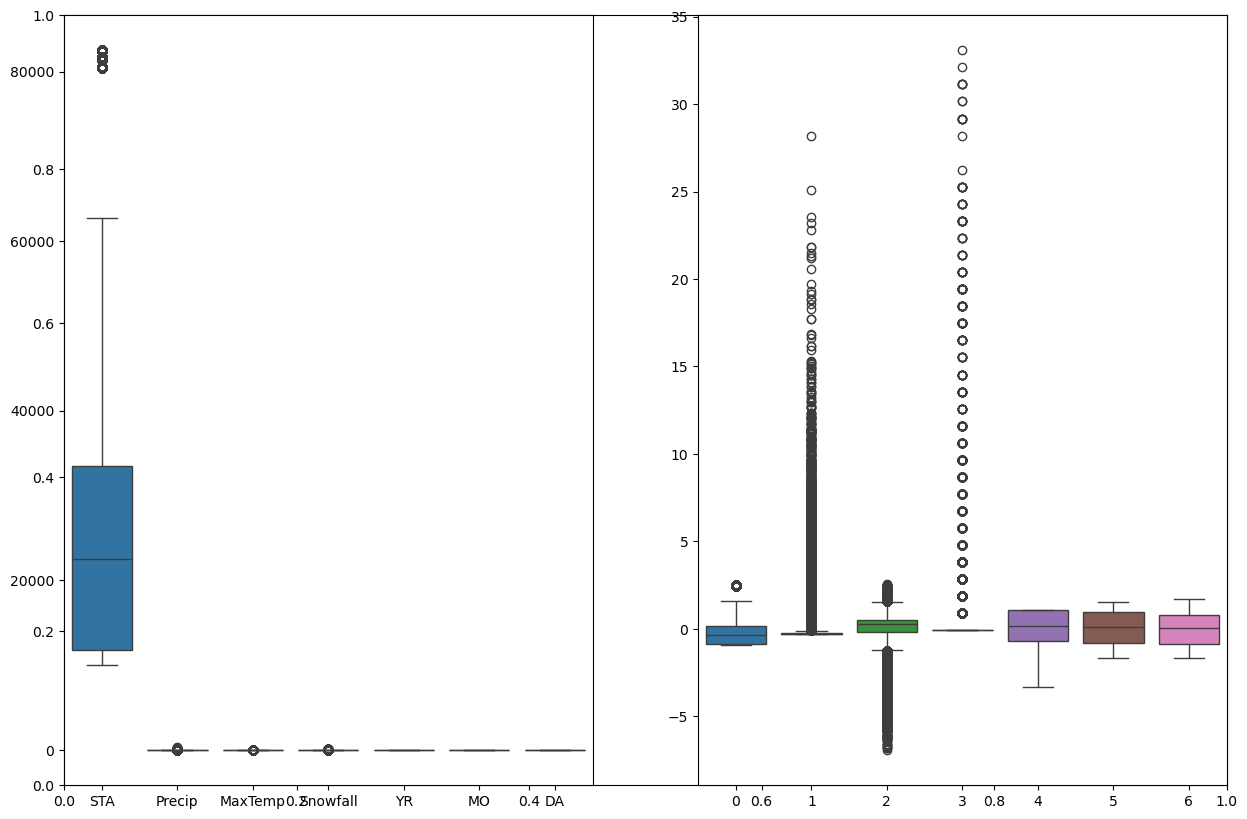

In [85]:
plt.subplots(figsize = (15,10))
plt.subplot(1,2,1)
sns.boxplot(data = X_train)
plt.subplot(1,2,2)
sns.boxplot(data = X_train_scaled)
plt.show()

In [86]:
!pip install lazypredict

In [87]:
from lazypredict import LazyRegressor

In [88]:
from sklearn import datasets

In [89]:
from sklearn.utils import shuffle

In [90]:
reg = LazyRegressor(verbose = 0, ignore_warnings = False, custom_metric = None)

In [91]:
regression = LinearRegression()

In [92]:
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [93]:
y_pred = regression.predict(X_test)

In [94]:
score = r2_score(y_test,y_pred)

In [95]:
score

0.9978492063201123

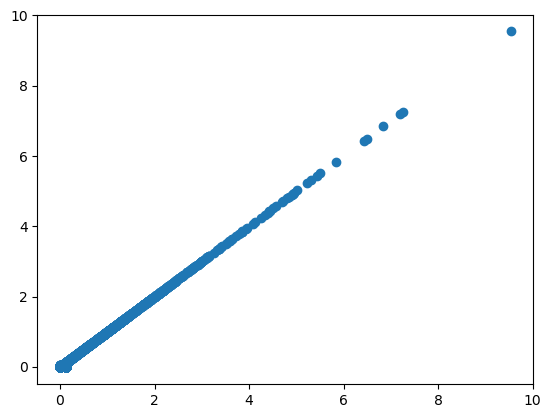

In [98]:
plt.scatter(y_test,y_pred)
plt.show()

Mean Absolute Error:  0.007690900425961333
Mean Squared Error:  0.00038279168961536097
R2 Score:  0.9978492060829495


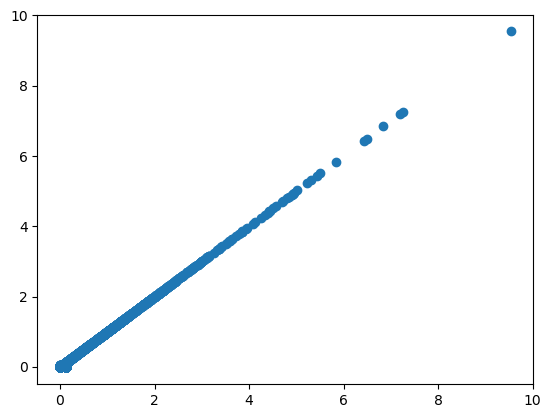

In [99]:
from sklearn.linear_model import RidgeCV
ridgecv = RidgeCV(cv = 5)
ridgecv.fit(X_train_scaled,y_train)
y_pred = ridgecv.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean Absolute Error: ", mae)
print("Mean Squared Error: ", mse)
print("R2 Score: ", score)
plt.scatter(y_test,y_pred)
plt.show()

Mean Absolute Error:  0.00763565455198488
Mean Squared Error:  0.00038419748783029647
R2 Score:  0.9978413073162539


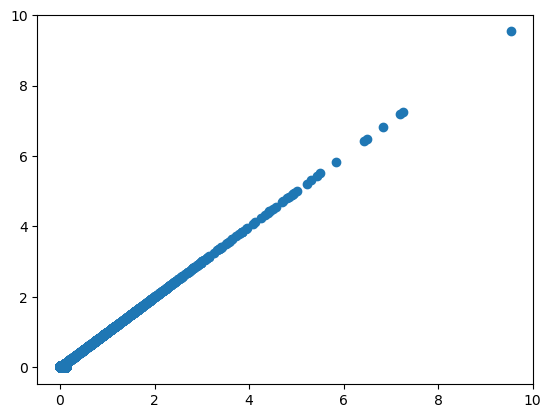

In [102]:
from sklearn.linear_model import LassoCV
lasso_cv = LassoCV(cv = 5)
lasso_cv.fit(X_train_scaled,y_train)
y_pred = lasso_cv.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean Absolute Error: ", mae)
print("Mean Squared Error: ", mse)
print("R2 Score: ", score)
plt.scatter(y_test,y_pred)
plt.show()

Mean Absolute Error:  0.007647525092750983
Mean Squared Error:  0.0003843958258678783
R2 Score:  0.997840192913156


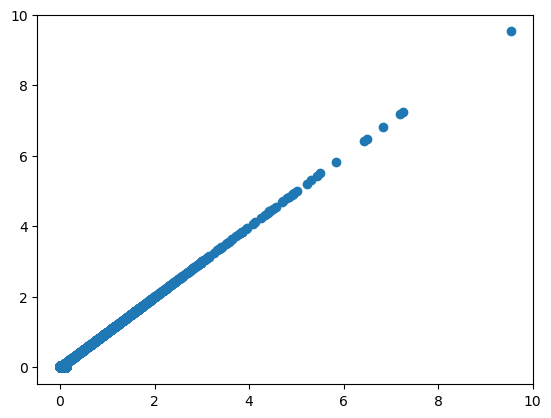

In [103]:
from sklearn.linear_model import ElasticNetCV
elasticnet_cv = ElasticNetCV(cv = 5)
elasticnet_cv.fit(X_train_scaled,y_train)
y_pred = elasticnet_cv.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean Absolute Error: ", mae)
print("Mean Squared Error: ", mse)
print("R2 Score: ", score)
plt.scatter(y_test,y_pred)
plt.show()